In [4]:
import pandas as pd
import requests
from pathlib import Path

# Fetch from CMS API using the direct endpoint
url = "https://data.cms.gov/data-api/v1/dataset/4ff7c618-4e40-483a-b390-c8a58c94fa15/data"
response = requests.get(url)
data = response.json()

# Print the structure
print(f"Type of data: {type(data)}")
print(f"Keys in data: {data.keys() if isinstance(data, dict) else 'Not a dict'}")

# Check if there's a 'results' key or similar
if isinstance(data, dict):
    print(f"\nTop-level keys: {list(data.keys())}")
    # Print first 500 chars to see structure
    print(f"\nFirst 500 characters:\n{str(data)[:500]}")

Type of data: <class 'list'>
Keys in data: Not a dict


In [6]:
import pandas as pd
import requests
from pathlib import Path

# Fetch from CMS API
url = "https://data.cms.gov/data-api/v1/dataset/4ff7c618-4e40-483a-b390-c8a58c94fa15/data"
response = requests.get(url)
data = response.json()

print(f"Type of data: {type(data)}")
print(f"Length: {len(data)}")
print(f"\nFirst record:")
print(data[0])

# Convert to DataFrame
df = pd.DataFrame(data)

print(f"\nShape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

Type of data: <class 'list'>
Length: 1000

First record:
{'Brnd_Name': '1st Tier Unifine Pentips', 'Gnrc_Name': 'Pen Needle, Diabetic', 'Tot_Mftr': '1', 'Mftr_Name': 'Overall', 'Year': '2025 (Q1-Q4)', 'Tot_Benes': '123', 'Tot_Clms': '215', 'Tot_Spndng': '6054.98', 'Avg_Spnd_Per_Bene': '49.23', 'Avg_Spnd_Per_Clm': '28.16', 'Drug_Uses': '"Drug uses not available"'}

Shape: (1000, 11)

Column names:
['Brnd_Name', 'Gnrc_Name', 'Tot_Mftr', 'Mftr_Name', 'Year', 'Tot_Benes', 'Tot_Clms', 'Tot_Spndng', 'Avg_Spnd_Per_Bene', 'Avg_Spnd_Per_Clm', 'Drug_Uses']

First few rows:
                       Brnd_Name             Gnrc_Name Tot_Mftr  \
0       1st Tier Unifine Pentips  Pen Needle, Diabetic        1   
1       1st Tier Unifine Pentips  Pen Needle, Diabetic        1   
2  1st Tier Unifine Pentips Plus  Pen Needle, Diabetic        1   
3  1st Tier Unifine Pentips Plus  Pen Needle, Diabetic        1   
4                       Abacavir      Abacavir Sulfate        7   

         Mftr_Name         

In [7]:
# Create data directory if it doesn't exist
Path("../data").mkdir(exist_ok=True)

# Save raw data
df.to_csv("../data/raw_spending.csv", index=False)
print("✓ Saved to data/raw_spending.csv")

# Basic exploration
print(f"\nDataset Overview:")
print(f"Total records: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"\nUnique years: {df['Year'].unique()}")
print(f"Unique drugs: {df['Brnd_Name'].nunique()}")
print(f"\nSample of data:")
print(df[['Brnd_Name', 'Gnrc_Name', 'Year', 'Tot_Spndng', 'Tot_Benes']].head(10))

# Convert numeric columns to actual numbers
numeric_cols = ['Tot_Benes', 'Tot_Clms', 'Tot_Spndng', 'Avg_Spnd_Per_Bene', 'Avg_Spnd_Per_Clm']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"\nNumeric columns converted:")
print(df[numeric_cols].describe())

✓ Saved to data/raw_spending.csv

Dataset Overview:
Total records: 1000
Total columns: 11

Unique years: <StringArray>
['2025 (Q1-Q4)']
Length: 1, dtype: str
Unique drugs: 253

Sample of data:
                       Brnd_Name             Gnrc_Name          Year  \
0       1st Tier Unifine Pentips  Pen Needle, Diabetic  2025 (Q1-Q4)   
1       1st Tier Unifine Pentips  Pen Needle, Diabetic  2025 (Q1-Q4)   
2  1st Tier Unifine Pentips Plus  Pen Needle, Diabetic  2025 (Q1-Q4)   
3  1st Tier Unifine Pentips Plus  Pen Needle, Diabetic  2025 (Q1-Q4)   
4                       Abacavir      Abacavir Sulfate  2025 (Q1-Q4)   
5                       Abacavir      Abacavir Sulfate  2025 (Q1-Q4)   
6                       Abacavir      Abacavir Sulfate  2025 (Q1-Q4)   
7                       Abacavir      Abacavir Sulfate  2025 (Q1-Q4)   
8                       Abacavir      Abacavir Sulfate  2025 (Q1-Q4)   
9                       Abacavir      Abacavir Sulfate  2025 (Q1-Q4)   

   Tot_Spndng 

Top 10 drugs by total spending:
                 Brnd_Name    Tot_Spndng  Tot_Benes
829          Anoro Ellipta  7.923526e+08   266976.0
830          Anoro Ellipta  7.923526e+08   266976.0
286                Adempas  7.914338e+08     6124.0
287                Adempas  7.914338e+08     6124.0
24        Abilify Maintena  6.739616e+08    30213.0
25        Abilify Maintena  6.739616e+08    30213.0
26     Abiraterone Acetate  6.005969e+08    61053.0
384  Albuterol Sulfate HFA  5.214667e+08  7260387.0
794               Amvuttra  4.000756e+08     1433.0
795               Amvuttra  4.000756e+08     1433.0


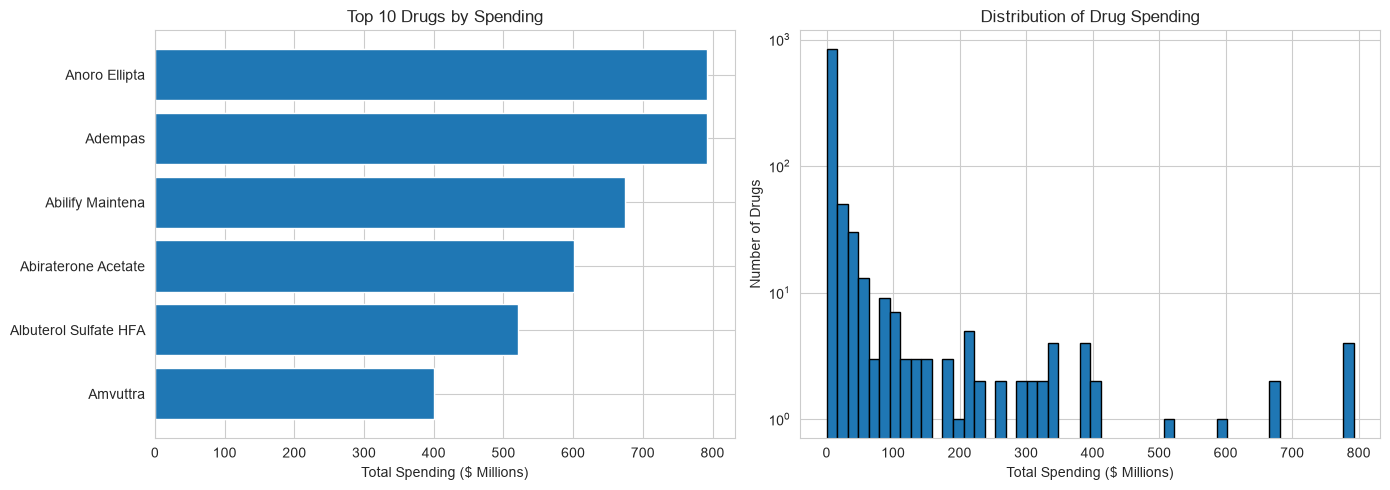


✓ Data exploration complete!


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Top 10 drugs by total spending
print("Top 10 drugs by total spending:")
top_drugs = df.nlargest(10, 'Tot_Spndng')[['Brnd_Name', 'Tot_Spndng', 'Tot_Benes']]
print(top_drugs)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Top 10 drugs by spending
top_10 = df.nlargest(10, 'Tot_Spndng')
axes[0].barh(top_10['Brnd_Name'], top_10['Tot_Spndng'] / 1e6)
axes[0].set_xlabel('Total Spending ($ Millions)')
axes[0].set_title('Top 10 Drugs by Spending')
axes[0].invert_yaxis()

# Plot 2: Distribution of spending
axes[1].hist(df['Tot_Spndng'] / 1e6, bins=50, edgecolor='black')
axes[1].set_xlabel('Total Spending ($ Millions)')
axes[1].set_ylabel('Number of Drugs')
axes[1].set_title('Distribution of Drug Spending')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print(f"\n✓ Data exploration complete!")